In [1]:
pip install -U -q datasets transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.0/527.0 kB 20.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 84.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 20.1 MB/s eta 0:00:00


In [2]:
from datasets import load_dataset
dataset = load_dataset("imdb")
print(dataset)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})


In [3]:
print(dataset['train'][0])

{'text': 'I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attentions to making some sort of documentary on what the average Swede thought about certain political issues such as the Vietnam War and race issues in the United States. In between asking politicians and ordinary denizens of Stockholm about their opinions on politics, she has sex with her drama teacher, classmates, and married men.<br /><br />What kills me about I AM CURIOUS-YELLOW is that 40 years ago, this was considered pornographic. Really, the sex and nudity scenes are few and far be

In [4]:
print(dataset['train'].features)

{'text': Value('string'), 'label': ClassLabel(names=['neg', 'pos'])}


In [5]:
print(dataset['train'][:3])
small_train = dataset['train'].shuffle(seed=42).select(range(2000))
print(len(small_train))

long_reviews = dataset['train'].filter(lambda x: len(x['text']) > 2000)
print(f"Number of long comments: {len(long_reviews)}")

split = dataset['train'].train_test_split(test_size=0.1, seed=42)
print(split)

{'text': ['I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attentions to making some sort of documentary on what the average Swede thought about certain political issues such as the Vietnam War and race issues in the United States. In between asking politicians and ordinary denizens of Stockholm about their opinions on politics, she has sex with her drama teacher, classmates, and married men.<br /><br />What kills me about I AM CURIOUS-YELLOW is that 40 years ago, this was considered pornographic. Really, the sex and nudity scenes are few and far b

Filter:   0%|          | 0/25000 [00:00<?, ? examples/s]

Number of long comments: 4322
DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 22500
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2500
    })
})


In [6]:
from transformers import AutoTokenizer
model_name = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_function(examples):
    return tokenizer(
        examples['text'],
        padding='max_length',
        truncation=True,
        max_length=256
        )

tokenized = dataset.map(tokenize_function, batched=True)
print(tokenized['train'].column_names)
print(len(tokenized['train'][0]['input_ids']))

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Map:   0%|          | 0/50000 [00:00<?, ? examples/s]

['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask']
256


In [7]:
print(len(tokenized['train']))

25000


In [8]:
tokenized = tokenized.remove_columns(['text'])
tokenized = tokenized.rename_column('label', 'labels')
tokenized.set_format('torch')

print(tokenized['train'].column_names)
print(tokenized['train'][0].keys())
print(tokenized['train'][0]['input_ids'].shape)
print(tokenized['train'][0]['labels'])

['labels', 'input_ids', 'token_type_ids', 'attention_mask']
dict_keys(['labels', 'input_ids', 'token_type_ids', 'attention_mask'])
torch.Size([256])
tensor(0)


In [9]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2
)

print(model)
print(model.classifier)
print(f"Total number of parameters: {sum(p.numel() for p in model.parameters()):,}")

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [10]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./results",

    # core parameters for training
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_ratio=0.1,

    # evaluation and save
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",

    # logs
    logging_steps=100,
    report_to="none",
    fp16=True,
    dataloader_num_workers=2
)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


In [20]:
!pip install -q evaluate
import numpy as np
import evaluate

accuracy_metric = evaluate.load("accuracy")
f1_metric = evaluate.load('f1')

def compute_metrics(eval_pred):
    """
    Trainer在evaluate时自动调用这个函数
    eval_pred = (logits, labels)
    """
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    acc = accuracy_metric.compute(predictions=predictions, references=labels)
    f1 = f1_metric.compute(predictions=predictions, references=labels)
    return {**acc, **f1}


In [21]:
from transformers import Trainer

split = tokenized['train'].train_test_split(test_size=0.1, seed=42)
train_dataset = split['train']
eval_dataset = split['test']
test_dataset = tokenized['test']

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    compute_metrics=compute_metrics
)
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.103411,0.499785,0.896400,0.890579
2,0.124492,0.352389,0.916800,0.915926
3,0.056835,0.424045,0.916000,0.915933


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=4221, training_loss=0.10905082437331799, metrics={'train_runtime': 1058.9524, 'train_samples_per_second': 63.742, 'train_steps_per_second': 3.986, 'total_flos': 8879998118400000.0, 'train_loss': 0.10905082437331799, 'epoch': 3.0})

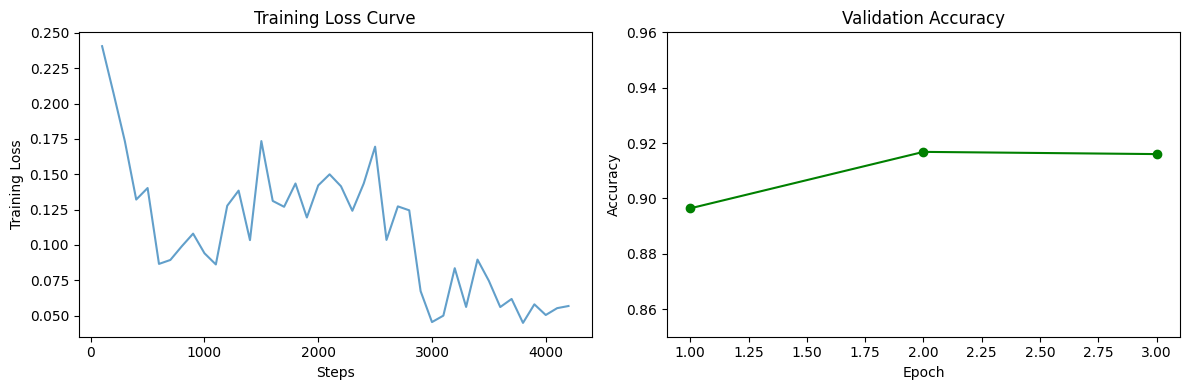

Best eval accuracy: 0.9168


In [23]:
import matplotlib.pyplot as plt

log_history = trainer.state.log_history
# get training loss
train_steps = [x['step'] for x in log_history if 'loss' in x]
train_losses = [x['loss'] for x in log_history if 'loss' in x]

# get evaluate loss
eval_epochs = [x['epoch'] for x in log_history if 'eval_loss' in x]
eval_losses = [x['eval_loss'] for x in log_history if 'eval_loss' in x]
eval_accs = [x['eval_accuracy'] for x in log_history if 'eval_accuracy' in x]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(train_steps, train_losses, alpha=0.7)
ax1.set_xlabel('Steps')
ax1.set_ylabel('Training Loss')
ax1.set_title('Training Loss Curve')

ax2.plot(eval_epochs, eval_accs, "o-", color='green')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Validation Accuracy')
ax2.set_ylim(0.85, 0.96)

plt.tight_layout()
plt.show()

print(f"Best eval accuracy: {max(eval_accs):.4f}")


In [24]:
print(log_history)

[{'loss': 0.24055238723754882, 'grad_norm': 6.041504859924316, 'learning_rate': 4.680851063829788e-06, 'epoch': 0.07107320540156362, 'step': 100}, {'loss': 0.20744495391845702, 'grad_norm': 4.573267459869385, 'learning_rate': 9.408983451536645e-06, 'epoch': 0.14214641080312723, 'step': 200}, {'loss': 0.17337295532226563, 'grad_norm': 12.120970726013184, 'learning_rate': 1.41371158392435e-05, 'epoch': 0.21321961620469082, 'step': 300}, {'loss': 0.1320988941192627, 'grad_norm': 14.939949989318848, 'learning_rate': 1.8865248226950357e-05, 'epoch': 0.28429282160625446, 'step': 400}, {'loss': 0.14025657653808593, 'grad_norm': 7.810746669769287, 'learning_rate': 1.959978936282254e-05, 'epoch': 0.35536602700781805, 'step': 500}, {'loss': 0.08659727096557618, 'grad_norm': 2.9233431816101074, 'learning_rate': 1.9073196419167984e-05, 'epoch': 0.42643923240938164, 'step': 600}, {'loss': 0.08938277244567872, 'grad_norm': 0.6006873846054077, 'learning_rate': 1.854660347551343e-05, 'epoch': 0.497512

In [27]:
# results = trainer.evaluate(eval_dataset=test_dataset)
# print(results)

predictions = trainer.predict(test_dataset)
print(f"Test accuracy: {predictions.metrics['test_accuracy']:.4f}")

Test accuracy: 0.9204


In [28]:
import torch

test_texts = [
    "This movie was absolutely fantastic! Great acting and storyline.",
    "Terrible film. Waste of time. The plot made no sense at all.",
    "It was okay, nothing special but not terrible either.",
]

model.eval()
device = model.device

for text in test_texts:
    inputs = tokenizer(text, return_tensors="pt", truncation=True,
                       padding=True, max_length=256).to(device)
    with torch.no_grad():
        outputs = model(**inputs)

    probs = torch.softmax(outputs.logits, dim=-1)
    pred = torch.argmax(probs, dim=-1).item()
    confidence = probs[0][pred].item()

    sentiment = "Positive 😊" if pred == 1 else "Negative 😞"
    print(f"Text: {text[:60]}...")
    print(f"  → {sentiment} (confidence: {confidence:.3f})")
    print()

Text: This movie was absolutely fantastic! Great acting and storyl...
  → Positive 😊 (confidence: 0.998)

Text: Terrible film. Waste of time. The plot made no sense at all....
  → Negative 😞 (confidence: 0.999)

Text: It was okay, nothing special but not terrible either....
  → Negative 😞 (confidence: 0.993)



In [29]:
save_path = "./my_imdb_bert"
model.save_pretrained(save_path)
tokenizer.save_pretrained(save_path)
print(f"Model saved to {save_path}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to ./my_imdb_bert


In [30]:
from transformers import TrainingArguments, Trainer
import gc, torch

results_lr = {}

for lr in [1e-5, 2e-5, 5e-5, 1e-4]:
    print(f"\n=== Testing lr={lr} ===")

    # 重新加载模型（每次从头开始）
    model_tmp = AutoModelForSequenceClassification.from_pretrained(
        "bert-base-uncased", num_labels=2
    )

    args_tmp = TrainingArguments(
        output_dir=f"./lr_exp_{lr}",
        num_train_epochs=1,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=32,
        learning_rate=lr,
        weight_decay=0.01,
        eval_strategy="epoch",
        logging_steps=200,
        fp16=True,
        report_to="none",
        save_strategy="no",  # 不保存 checkpoint 省空间
    )

    trainer_tmp = Trainer(
        model=model_tmp,
        args=args_tmp,
        train_dataset=train_dataset,
        eval_dataset=eval_dataset,
        compute_metrics=compute_metrics,
    )

    trainer_tmp.train()
    eval_result = trainer_tmp.evaluate()
    results_lr[lr] = eval_result["eval_accuracy"]
    print(f"lr={lr}: accuracy={eval_result['eval_accuracy']:.4f}")

    # 清理 GPU 内存
    del model_tmp, trainer_tmp
    gc.collect()
    torch.cuda.empty_cache()

# 打印汇总
print("\n=== LR Comparison ===")
for lr, acc in sorted(results_lr.items()):
    bar = "█" * int(acc * 100 - 85)
    print(f"lr={lr:.0e}: {acc:.4f} {bar}")


=== Testing lr=1e-05 ===


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.251998,0.235033,0.909600,0.910883


RuntimeError: on_train_begin must be called before on_evaluate

In [ ]:
# BERT 的强大之处：少量数据也能 fine-tune 出好效果
# 对比 500 / 2000 / 5000 / 全量（22500）条训练数据

results_size = {}
for n in [500, 2000, 5000]:
    print(f"\n=== Training with {n} samples ===")

    small_train = train_dataset.shuffle(seed=42).select(range(n))

    model_tmp = AutoModelForSequenceClassification.from_pretrained(
        "bert-base-uncased", num_labels=2
    )

    args_tmp = TrainingArguments(
        output_dir=f"./size_exp_{n}",
        num_train_epochs=3,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=32,
        learning_rate=2e-5,
        eval_strategy="epoch",
        logging_steps=50,
        fp16=True,
        report_to="none",
        save_strategy="no",
    )

    trainer_tmp = Trainer(
        model=model_tmp, args=args_tmp,
        train_dataset=small_train, eval_dataset=eval_dataset,
        compute_metrics=compute_metrics,
    )
    trainer_tmp.train()
    eval_result = trainer_tmp.evaluate()
    results_size[n] = eval_result["eval_accuracy"]

    del model_tmp, trainer_tmp
    gc.collect()
    torch.cuda.empty_cache()

print("\n=== Data Size Comparison ===")
for n, acc in sorted(results_size.items()):
    print(f"{n:>6} samples: {acc:.4f}")
